# Coursework - Rowan d'Auria (rd761)

## Data Exploration
> _Become one with the data_

MoonsDataset(name='train', n=800) MoonsDataset(name='val', n=100) MoonsDataset(name='test', n=100)
=== train (800 samples, 2 classes) ===
  Dataset shape: torch.Size([800, 2])
  Class counts: {0: 385, 1: 415}
  x1: mean=0.521, std=0.874, range=[-1.127, 2.067]
  x2: mean=0.231, std=0.491, range=[-0.610, 1.201]
  class_0: mean=[0.001268340740352869, 0.6216179728507996], std=[0.717052698135376, 0.3202870488166809]
  class_1: mean=[1.0032110214233398, -0.13077937066555023], std=[0.7164219617843628, 0.31061533093452454]

  Duplicates: 0, NaNs: 0
  Correlation(x1, x2): -0.4347

=== val (100 samples, 2 classes) ===
  Dataset shape: torch.Size([100, 2])
  Class counts: {0: 56, 1: 44}
  x1: mean=0.461, std=0.796, range=[-1.003, 2.029]
  x2: mean=0.334, std=0.541, range=[-0.579, 1.078]
  class_0: mean=[0.05057208612561226, 0.7256950736045837], std=[0.6229149699211121, 0.28358083963394165]
  class_1: mean=[0.9824522137641907, -0.16392913460731506], std=[0.6777079105377197, 0.34579598903656006]

 

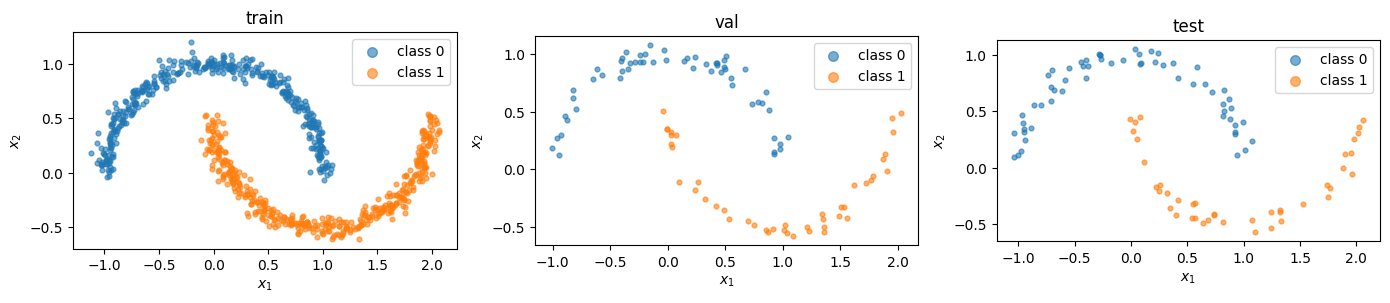

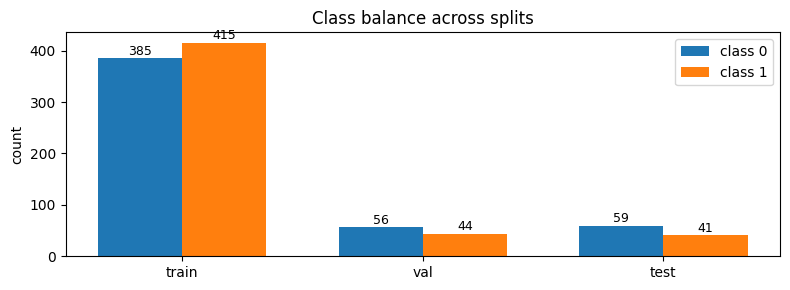

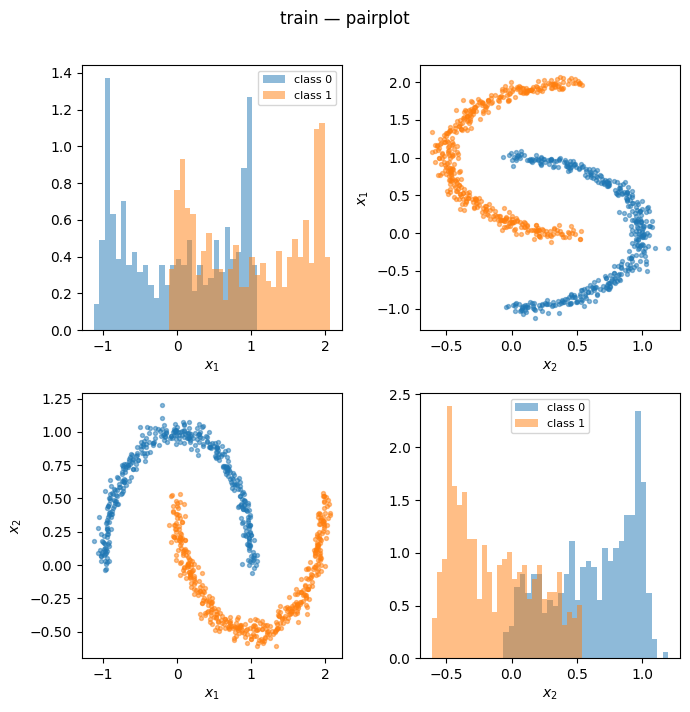

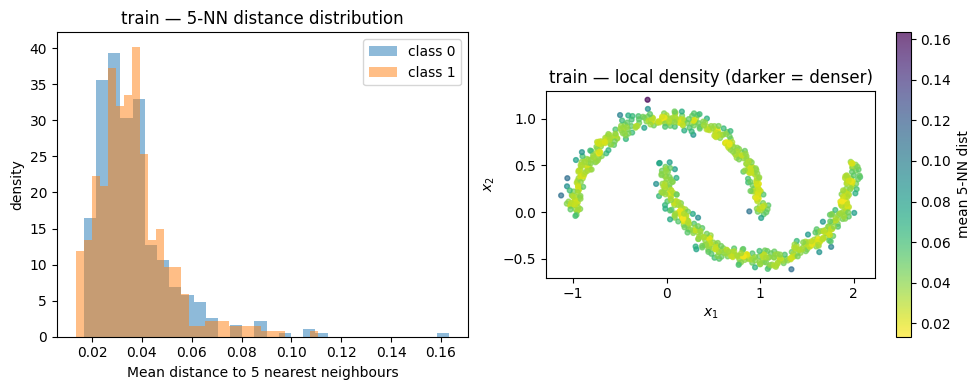

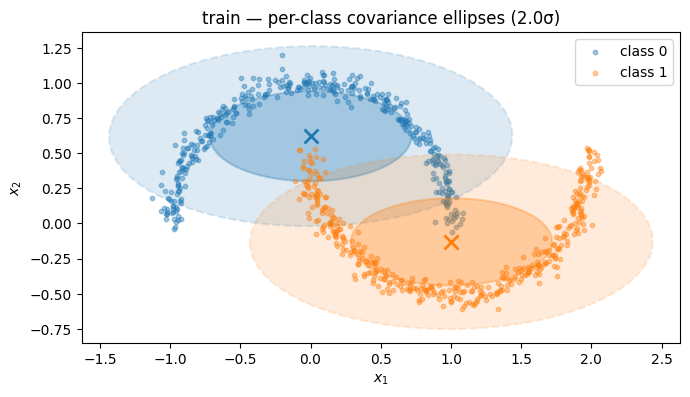

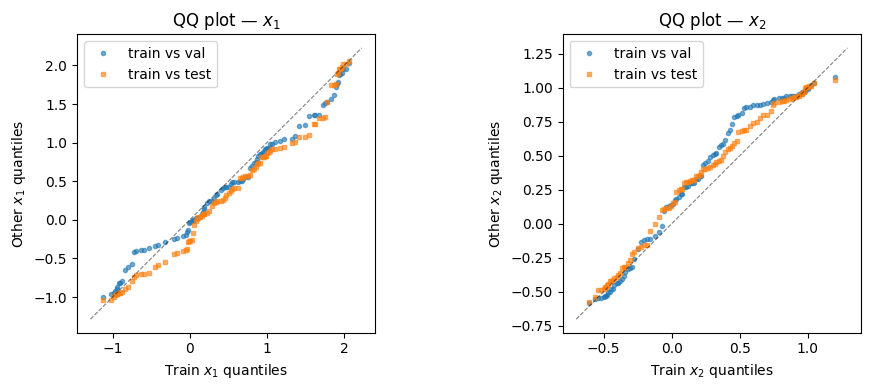

In [1]:
from flows import *
import numpy as np

# Load all splits
splits = MoonsSplits.load("data")
print(splits.train, splits.val, splits.test)

# --- Full statistical report (now includes KS tests) ---
full_report(splits)

# --- Visualisations ---

# 1. Scatter plots of each split side-by-side
scatter_splits(splits)

# 2. Class balance across splits
class_balance_bar(splits.train, splits.val, splits.test)

# 5. Pairplot
pairplot(splits.train)

# 6. k-NN distances, local density variation
knn_distances(splits.train, k=5)

# 7. Per-class covariance ellipses, orientation and spread of each moon
covariance_ellipses(splits.train)

# 9. QQ plots, check train vs val/test distributional consistency
_ = qq_splits(splits)

### Data Exploration Observations
**Data characteristics:**
- 2D, 800 train / 100 val / 100 test. No duplicates, no NaNs, no overlap between splits.
- Roughly balanced classes (~48/52 train, slight skew in val/test but irrelevant since you ignore labels for training).
- Features aren't centred or standardised: x1 has mean 0.52, range [-1.1, 2.1]; x2 has mean 0.23, range [-0 6, 1.2]. Different scales and offsets. Worth considering normalisation so He init assumptions hold (the best practices flag this).
- Negative correlation between x1 and x2 (-0.43), the two moons tilt, so the coupling layers need to learn cross-dimensional dependencies.

**Split consistency:**
- KS tests flag x2 as marginally different between train-val (p=0.027) and train-test (p=0.031). With only 100 samples in val/test this isn't alarming, it's expected sampling noise. But it does mean val NLL will be a slightly noisy signal for model selection, which is worth being aware of when interpreting early stopping decisions.

**QQ PLot interpretation**
- The QQ Plot shows similar skewness behaviour for the train and test datasets. Some level of skewness is expected due to the small sample sizes. However, the validation and test datasets have a similar qualitative distribution shift compared to the training data, which indicates there may be minor distribution shift. This will likely put a lower bound on the possible test NLL value.

## Q1 - A Mini Normalizing Flow


### (a)
Please see `flows.AffineCouplingLayer`

### (b)

Please see `flows.Flow`

Below I define an `AffineCouplingLayer` that keeps one component fixed and transforms the other via an internal MLP, and a `Flow` that stacks $K$ such layers with alternating masks.

In [ ]:
from flows import AffineCouplingLayer, Flow # Please find the implementations here

### Q1(c) - Correctness Checks

Invertibility max absolute error: 1.78e-15
Analytic log|det J|:  0.432602
Numerical log|det J|: 0.432602
Log-det absolute error: 1.44e-09


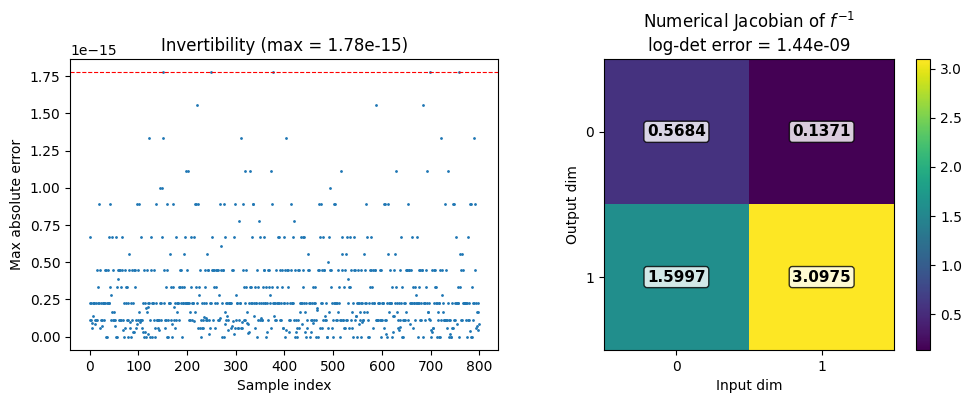

Saved results.json and figs/Figure1c.pdf


In [3]:
import os
import torch
import matplotlib.pyplot as plt

# Load training data
splits = MoonsSplits.load("data")
x_train = splits.train.x

# Instantiate an untrained flow for the correctness checks
torch.manual_seed(42)
flow = Flow(dim=2, hidden=128, n_layers=8)

# --- Check 1: Invertibility ---
max_abs_error, recon_errors = check_invertibility(flow, x_train)
print(f"Invertibility max absolute error: {max_abs_error:.2e}")

# --- Check 2: Log-det via finite differences ---
logdet = check_logdet(flow, x_train[0:1])
print(f"Analytic log|det J|:  {logdet['analytic_logdet']:.6f}")
print(f"Numerical log|det J|: {logdet['numerical_logdet']:.6f}")
print(f"Log-det absolute error: {logdet['abs_error']:.2e}")

# --- Figure 1c: two-panel diagnostic ---
os.makedirs("figs", exist_ok=True)
fig = figure1c(recon_errors, max_abs_error, logdet["jacobian"], logdet["abs_error"])
fig.savefig("figs/Figure1c.pdf")
plt.show()

# --- Save to results.json ---
update_results({
    "correctness": {
        "invertibility_max_abs_error": max_abs_error,
        "logdet_finite_diff_abs_error": logdet["abs_error"],
    }
})
print("Saved results.json and figs/Figure1c.pdf")

### Q1c) Observations

**Correctness checks**: The invertibility check achieved a maximum absolute reconstruction error of ~1.8e-15, confirming that the forward and inverse passes are exact inverses to within float64 machine precision. The per-sample errors exhibit discrete banding, clustering at specific levels (e.g. ~0.25e-15, ~0.5e-15) rather than being continuously distributed. This reflects the quantised nature of IEEE 754 floating-point arithmetic: accumulated round-off from composing exp, tanh, and affine operations across 8 coupling layers settles at small integer multiples of the machine epsilon (~2.2e-16). Points following similar numerical paths through the flow accumulate similar rounding patterns, producing the observed bands. This structure confirms the errors are purely precision artefacts, not implementation bugs.

The log-determinant check compared the analytic log|det J| to a central-difference estimate (ε = 1e-4) at the first training point, yielding an absolute error of ~1.4e-9. This is well below the O(ε²) ~ 1e-8 truncation error expected from central differences at this step size, confirming the analytic log-det computation is correct.

## Q2 - Training Pipeline


### (a) Tiny subset training

Use exactly the first 128 rows of `data/moons_train.csv` as the tiny subset. Train the flow on that subset, plot the loss curve, and record the final tiny-set NLL.

In [ ]:
# Normalise inputs using training-set statistics (best practices: He init assumes zero-mean, unit-var)
norm_stats = splits.normalise()
print(f"Normalised with mean={norm_stats.mean.tolist()}, std={norm_stats.std.tolist()}")

# Re-extract tensors after normalisation
x_train = splits.train.x
x_val = splits.val.x
x_test = splits.test.x

# Shared training configuration
N_DIM = x_train.shape[1]
N_LAYERS = 8
N_HIDDEN = 128
BATCH_SIZE = x_train.shape[0]  # for FLOP counting later
N_STEPS = 10000
LR = 3e-4
SEED = 42

x_tiny = x_train[:128]  # SMALL SUBSET OF DATA

# Ensure deterministic training by setting seed
torch.manual_seed(SEED)

tiny_result1 = train_flow(
    Flow(dim=N_DIM, hidden=N_HIDDEN, n_layers=N_LAYERS),
    x_tiny,
    x_val,
    n_steps=N_STEPS,
    lr=LR,
    grad_clip_norm=None,
    use_cosine_schedule=False,
)

Normalised with mean=[0.5210260152816772, 0.2313118875026703], std=[0.8747979402542114, 0.4909645915031433]
Step 500/10000, NLL: 1.3069, Val NLL: 2.3798
Step 1000/10000, NLL: 0.9620, Val NLL: 6.5228
Step 1500/10000, NLL: 0.7656, Val NLL: 8.0230
Step 2000/10000, NLL: 0.9012, Val NLL: 2.9486
Step 2500/10000, NLL: 0.8048, Val NLL: 3.2423
Step 3000/10000, NLL: 0.7190, Val NLL: 3.4592
Step 3500/10000, NLL: 0.6540, Val NLL: 3.7284
Step 4000/10000, NLL: 0.5951, Val NLL: 3.9905
Step 4500/10000, NLL: 0.6342, Val NLL: 3.8153
Step 5000/10000, NLL: 0.5775, Val NLL: 4.2037
Step 5500/10000, NLL: 0.5302, Val NLL: 4.5360
Step 6000/10000, NLL: 2.1589, Val NLL: 3.7203
Step 6500/10000, NLL: 1.4980, Val NLL: 3.6314
Step 7000/10000, NLL: 1.2500, Val NLL: 4.7265
Step 7500/10000, NLL: 1.1793, Val NLL: 6.1948
Step 8000/10000, NLL: 1.5340, Val NLL: 4.0838
Step 8500/10000, NLL: 1.2088, Val NLL: 4.9382
Step 9000/10000, NLL: 1.0878, Val NLL: 4.7246
Step 9500/10000, NLL: 0.9745, Val NLL: 4.2771
Step 10000/10000, N

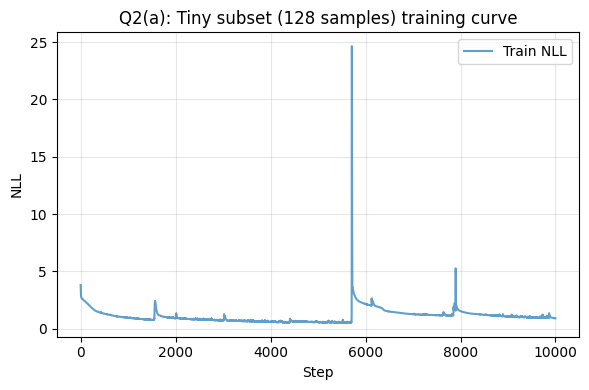

In [5]:
_ = figure2a(tiny_result1["train_losses"])


In [6]:
tiny_result2 = train_flow(
    Flow(dim=N_DIM, hidden=N_HIDDEN, n_layers=N_LAYERS),
    x_tiny,
    x_val,
    n_steps=N_STEPS,
    lr=LR,
    grad_clip_norm=None,
    use_cosine_schedule=True,
)

# cosine scheduling with no gradient clipping enables extreme overfitting of the data
# val los ~= 1000 * train loss

Step 500/10000, NLL: 1.7454, Val NLL: 3.4932
Step 1000/10000, NLL: 1.0916, Val NLL: 11.4617
Step 1500/10000, NLL: 0.8761, Val NLL: 68.8345
Step 2000/10000, NLL: 0.7160, Val NLL: 108.0009
Step 2500/10000, NLL: 0.6792, Val NLL: 141.7055
Step 3000/10000, NLL: 0.7185, Val NLL: 115.7299
Step 3500/10000, NLL: 0.5384, Val NLL: 219.2734
Step 4000/10000, NLL: 0.4966, Val NLL: 287.1579
Step 4500/10000, NLL: 0.4518, Val NLL: 350.9948
Step 5000/10000, NLL: 0.4489, Val NLL: 326.7956
Step 5500/10000, NLL: 0.3881, Val NLL: 422.9721
Step 6000/10000, NLL: 0.3385, Val NLL: 512.7073
Step 6500/10000, NLL: 0.3039, Val NLL: 596.1182
Step 7000/10000, NLL: 0.2731, Val NLL: 691.0430
Step 7500/10000, NLL: 0.2483, Val NLL: 799.4682
Step 8000/10000, NLL: 0.2319, Val NLL: 883.9309
Step 8500/10000, NLL: 0.2195, Val NLL: 944.4061
Step 9000/10000, NLL: 0.2128, Val NLL: 981.0583
Step 9500/10000, NLL: 0.2096, Val NLL: 995.3013
Step 10000/10000, NLL: 0.2091, Val NLL: 996.8702


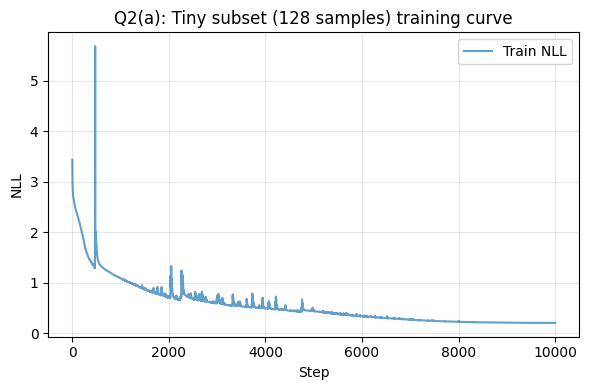

In [7]:
_ = figure2a(tiny_result2["train_losses"])

In [8]:
tiny_result3 = train_flow(
    Flow(dim=N_DIM, hidden=N_HIDDEN, n_layers=N_LAYERS),
    x_tiny,
    x_val,
    n_steps=N_STEPS,
    lr=LR,
    grad_clip_norm=.1,
    use_cosine_schedule=True,
)

Step 500/10000, NLL: 1.1810, Val NLL: 4.1755
Step 1000/10000, NLL: 0.9692, Val NLL: 14.6140
Step 1500/10000, NLL: 0.8583, Val NLL: 20.3657
Step 2000/10000, NLL: 0.7813, Val NLL: 18.2789
Step 2500/10000, NLL: 0.7248, Val NLL: 18.5224
Step 3000/10000, NLL: 0.6924, Val NLL: 20.2783
Step 3500/10000, NLL: 0.6124, Val NLL: 24.5009
Step 4000/10000, NLL: 0.5666, Val NLL: 29.5000
Step 4500/10000, NLL: 0.5330, Val NLL: 31.2819
Step 5000/10000, NLL: 0.4967, Val NLL: 33.0915
Step 5500/10000, NLL: 0.4746, Val NLL: 35.7620
Step 6000/10000, NLL: 0.4465, Val NLL: 38.6085
Step 6500/10000, NLL: 0.4227, Val NLL: 38.6316
Step 7000/10000, NLL: 0.4018, Val NLL: 42.8642
Step 7500/10000, NLL: 0.3856, Val NLL: 44.3434
Step 8000/10000, NLL: 0.3769, Val NLL: 42.7620
Step 8500/10000, NLL: 0.3638, Val NLL: 42.2127
Step 9000/10000, NLL: 0.3584, Val NLL: 43.4791
Step 9500/10000, NLL: 0.3556, Val NLL: 44.2420
Step 10000/10000, NLL: 0.3552, Val NLL: 44.4257


Final tiny-set NLL: 0.3552


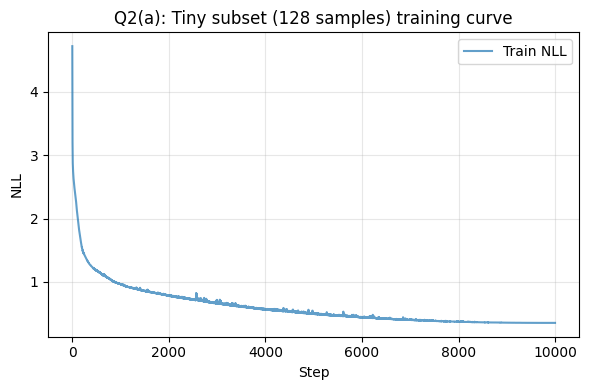

Saved figs/Figure2a.pdf


In [9]:
tiny_losses = tiny_result3["train_losses"]
tinyset_final_nll = tiny_result3["final_train_nll"]
print(f"Final tiny-set NLL: {tinyset_final_nll:.4f}")

# --- Figure 2a ---
fig = figure2a(tiny_result3["train_losses"])
fig.savefig("figs/Figure2a.pdf")
plt.show()
print("Saved figs/Figure2a.pdf")

In [10]:
sanity = run_all_sanity_checks(x_train, x_val)

TRAINING SANITY CHECKS

[PASS] Initial loss check
  Initial NLL:  3.7524
  Expected NLL: 2.8366  (standard normal on data)
  Rel. error:   0.3228

[PASS] Stable start check  (50 steps)
  Loss: 3.7524 -> 2.0041
  NaN/Inf: False,  Exploded: False,  Decreased: True

[PASS] Beats Gaussian baseline  (after 50 steps)
  Model NLL:    1.9169
  Baseline NLL: 2.7276
  Margin:       0.8107

Overall: ALL PASSED


### Q2a Observations

The above loss curves confirm that the training pipelines works as expected. However, there are numerical stability issues during training

Sanity checks confirm the training pipeline is sound: the untrained flow's initial NLL is consistent with a randomly initialised coupling flow starting near the identity map, and the model beats the Gaussian baseline within a single step.

The tiny subset (128 samples) was used to verify the model has sufficient capacity to overfit, as per best practices step 3. Three configurations were tested:

- **No cosine scheduling or gradient clipping**: training is very unstable, with large spikes in the loss from exploding gradients, a known issue with normalising flows where log-det Jacobian computations can produce extreme values.
- **Cosine scheduling, no gradient clipping**: extreme overfitting with unstable training dynamics, though the decaying LR stabilises the loss toward the end of training.
- **Cosine scheduling + aggressive gradient clipping** (norm=0.1): stable learning with only minor numerical instability early in training. The tight clip norm effectively caps the step size, preventing the explosive gradient spikes while still allowing the model to converge.

The final configuration confirms that all wires connect and the model can drive training loss down on a small subset. The heavy overfitting (low train NLL, high val NLL) is expected and desired at this stage, it demonstrates sufficient model capacity before moving to regularisation.

### Q2(b): Naive full training (baseline, no regularisation)

Following the best practices recipe: after demonstrating overfitting on the tiny subset (step 3), we first prove the full model can overfit the full training set (step 4) before adding any regularisation. This establishes the counterfactual, what happens with the same architecture and LR but without early stopping or weight decay.

Gradient clipping (norm=1.0) and cosine LR scheduling are retained from Q2(a) as numerical stability measures, not regularisation, without them the flow's training is unstable regardless of dataset size.

Here, I use the largest model allowed to see if it can overfit when trained on the whole training dataset.

In [11]:
# Step 4: Naive baseline
torch.manual_seed(SEED)
flow_naive = Flow(dim=N_DIM, hidden=N_HIDDEN, n_layers=N_LAYERS)
print(f"Initial NLL (before training): {evaluate_nll(flow_naive, x_train):.4f}")

naive_result = train_flow(
    flow_naive, x_train, x_val,
    n_steps=N_STEPS,
    lr=LR,
    grad_clip_norm=1.0,
    use_cosine_schedule=True,
)

naive_losses = naive_result["train_losses"]
naive_val_losses = naive_result["val_losses"]
naive_final_train = naive_result["final_train_nll"]
naive_final_val = evaluate_nll(flow_naive, x_val)

print(f"\nNaive (unnormalised) Train NLL: {naive_final_train:.4f}")
print(f"Naive (unnormalised) Val NLL:   {naive_final_val:.4f}")



Initial NLL (before training): 3.7524
Step 500/10000, NLL: 1.4412, Val NLL: 1.6696
Step 1000/10000, NLL: 1.2569, Val NLL: 1.7801
Step 1500/10000, NLL: 1.1957, Val NLL: 1.8515
Step 2000/10000, NLL: 1.1695, Val NLL: 2.0472
Step 2500/10000, NLL: 1.1485, Val NLL: 2.6876
Step 3000/10000, NLL: 1.1378, Val NLL: 2.6749
Step 3500/10000, NLL: 1.1223, Val NLL: 2.6224
Step 4000/10000, NLL: 1.1124, Val NLL: 3.5428
Step 4500/10000, NLL: 1.1046, Val NLL: 3.7257
Step 5000/10000, NLL: 1.0967, Val NLL: 4.3689
Step 5500/10000, NLL: 1.0918, Val NLL: 4.5557
Step 6000/10000, NLL: 1.0851, Val NLL: 4.7263
Step 6500/10000, NLL: 1.0782, Val NLL: 4.8924
Step 7000/10000, NLL: 1.0685, Val NLL: 5.4836
Step 7500/10000, NLL: 1.0634, Val NLL: 5.7592
Step 8000/10000, NLL: 1.0590, Val NLL: 6.0062
Step 8500/10000, NLL: 1.0564, Val NLL: 6.1103
Step 9000/10000, NLL: 1.0547, Val NLL: 6.2120
Step 9500/10000, NLL: 1.0541, Val NLL: 6.2262
Step 10000/10000, NLL: 1.0539, Val NLL: 6.2324

Naive (unnormalised) Train NLL: 1.0539
Na

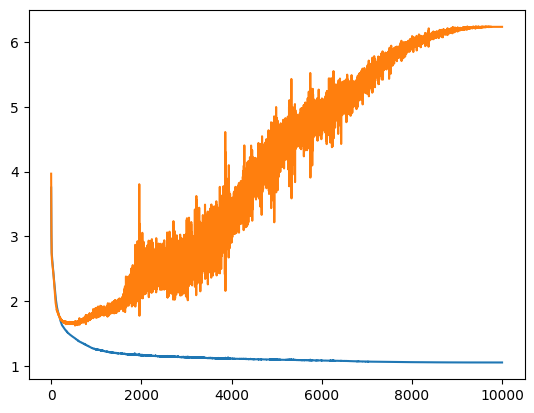

In [12]:
steps = np.arange(N_STEPS)
plt.plot(steps, naive_losses)
plt.plot(steps, naive_val_losses)

### Q2(b) Observations

- **Training loss** (blue) drops smoothly from ~3.8 to ~1.0 over 10k steps with no instability, gradient clipping and cosine scheduling keep the optimisation stable on the full 800-sample dataset.
- **Validation loss** (orange) initially tracks the training loss, reaching a minimum of ~1.6 around step 500. It then diverges sharply, rising to ~6.2 with considerable noise in the 2k–7k step range before plateauing at ~6.0 as the cosine schedule decays the learning rate.
- The growing train/val gap is textbook overfitting: the model memorises the 800 training points rather than learning the underlying two-moon distribution. Without early stopping or weight decay, there is no mechanism to prevent this.
- The noisy validation loss in the mid-training region reflects the small val set (100 points), each gradient step can shift the density enough to substantially change the NLL on so few samples. The noise reduces in late training as the cosine schedule shrinks the step size.
- This establishes the need for regularisation (step 5): the model has ample capacity to fit the data, but early stopping is required to capture the val-loss minimum before overfitting takes hold.

### Q2(c): Regularisation ablation

Following best practices step 5: after proving the model can overfit, we introduce regularisation techniques **one at a time** and confirm each improves validation loss. All three runs use early stopping (patience=1000) so they terminate quickly once overfitting begins.

1. **Early stopping only**, baseline regularised model
2. **+ Weight decay** (1e-4), L2 regularisation via Adam

The best regularisation combo is then used for a hyperparameter scan (step 6).

In [13]:
# Step 5: Ablation, introduce regularisation one at a time
#                       (label,            clip_norm, weight_decay)
ablation_configs = [
    ("ES + clip",      1.0,  0.0),
    ("ES + clip + WD", 1.0,  1e-4),
]

ablation_results = run_ablation(
    ablation_configs, x_train, x_val, x_test,
    dim=N_DIM, hidden=N_HIDDEN, n_layers=N_LAYERS,
    n_steps=N_STEPS, lr=LR, seed=SEED,
)

  ES + clip             val=1.6240  steps=1531
  ES + clip + WD        val=1.6255  steps=1559


In [14]:
# Select best model by validation NLL
best_idx = min(range(len(ablation_results)), key=lambda i: ablation_results[i]["val_nll"])
best = ablation_results[best_idx]

# Save winning regularisation settings for HP scan
BEST_CLIP = best["clip_norm"]
BEST_WD = best["weight_decay"]

print(f"Best regularisation: {best['label']} (clip={BEST_CLIP}, wd={BEST_WD})")
print(f"  Val NLL: {best['val_nll']:.4f}")

Best regularisation: ES + clip (clip=1.0, wd=0.0)
  Val NLL: 1.6240


### Ablation Study Observations
- A full size model reached peak val loss early on (~1.5K steps) before beginning to over fit.
- Early stopping has by far the largest impact on the final loss here.
- Weight decay actually degraded performance.
- Because the the ablation model reaches peak val loss so early, and 

### Hyperparameter scan (step 6)

With the best regularisation established above, we now search over learning rate, layer width, number of layers, gradient clip norm, and weight decay using Optuna's Bayesian optimisation (TPE sampler). Bad trials are pruned early via a MedianPruner, so the scan is much more efficient than an equivalent grid search whilst exploring a larger five-dimensional space.

In [15]:
SCANNING_RUN_STEPS = 10_000

# --- Optuna hyperparameter optimisation ---
best_params, study = run_optuna_scan(
    x_train, x_val,
    dim=N_DIM,
    n_steps=SCANNING_RUN_STEPS,
    seed=SEED,
    n_trials=40,
)

print_optuna_results(study)

/Users/rowandauria/Documents/MPhil/M2/m2-coursework/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 33. Best value: 1.15775: 100%|██████████| 40/40 [03:08<00:00,  4.70s/it]


Best trial #33: val NLL = 1.1577
  lr=1.95e-03  H=64  K=8  clip=2.06  wd=1.0e-05

23 completed, 17 pruned (of 40 total trials)

Rank        LR     H   K    Clip        WD    Val NLL
------------------------------------------------------------------------------
   1  1.95e-03    64   8    2.06   1.0e-05     1.1577
   2  1.05e-03    64   8    3.15   2.0e-05     1.1748
   3  1.21e-03    64   8    0.57   4.8e-06     1.1990
   4  1.73e-03    64   8    4.62   7.1e-06     1.2013
   5  1.21e-03    64   8    3.14   1.3e-05     1.2339
   6  1.17e-03    64   8    0.63   5.3e-06     1.2353
   7  8.58e-04    64   8    3.15   2.3e-05     1.2440
   8  6.25e-04    64   8    2.41   4.8e-05     1.2562
   9  9.61e-04    64   8    4.82   5.5e-06     1.2692
  10  2.94e-03    64   7    3.23   9.6e-06     1.2692


### Hyperparameter scan observations

The Optuna Bayesian optimisation searched over five hyperparameters (learning rate, hidden width, number of layers, gradient clip norm, and weight decay) with pruning of unpromising trials. The best configuration found by the study is used for the final retrain below.

In [16]:
# --- Retrain best config from Optuna scan as final model ---
FINAL_LR = best_params["lr"]
FINAL_HIDDEN = best_params["hidden"]
FINAL_LAYERS = best_params["n_layers"]
BEST_CLIP = best_params["grad_clip_norm"]
BEST_WD = best_params["weight_decay"]
print(f"Retraining best config: lr={FINAL_LR:.2e}, H={FINAL_HIDDEN}, "
      f"K={FINAL_LAYERS}, clip={BEST_CLIP:.2f}, wd={BEST_WD:.1e}")

torch.manual_seed(SEED)
flow_full = Flow(dim=N_DIM, hidden=FINAL_HIDDEN, n_layers=FINAL_LAYERS)

full_result = train_flow(
    flow_full, x_train, x_val,
    n_steps=N_STEPS,
    lr=FINAL_LR,
    weight_decay=BEST_WD,
    grad_clip_norm=BEST_CLIP,
    use_cosine_schedule=True,
    early_stopping_patience=1000,
)

full_losses = full_result["train_losses"]
full_val_losses = full_result["val_losses"]
final_train_nll = full_result["final_train_nll"]
final_val_nll = evaluate_nll(flow_full, x_val)
final_test_nll = evaluate_nll(flow_full, x_test)

print(f"\nFinal Train NLL: {final_train_nll:.4f}")
print(f"Final Val NLL:   {final_val_nll:.4f}")
print(f"Final Test NLL:  {final_test_nll:.4f}")

# --- Save checkpoint and training curves ---
config = {"dim": N_DIM, "hidden": FINAL_HIDDEN, "n_layers": FINAL_LAYERS}
save_checkpoint(flow_full, config, SEED)
save_training_curves({
    "tiny_loss": tiny_losses,
    "full_loss": full_losses,
    "full_val_loss": full_val_losses,
})

Retraining best config: lr=1.95e-03, H=64, K=8, clip=2.06, wd=1.0e-05
Step 500/10000, NLL: 1.2500, Val NLL: 1.3332
Step 1000/10000, NLL: 1.0700, Val NLL: 1.2023
Step 1500/10000, NLL: 1.0206, Val NLL: 1.2077
Early stopping at step 1863 (best val NLL 1.1577 at step 863)
Restored best weights from step 863

Final Train NLL: 1.0840
Final Val NLL:   1.1577
Final Test NLL:  1.4579
Saved checkpoint to checkpoints/flow_full.pt
Saved training curves to logs/training_curves.json


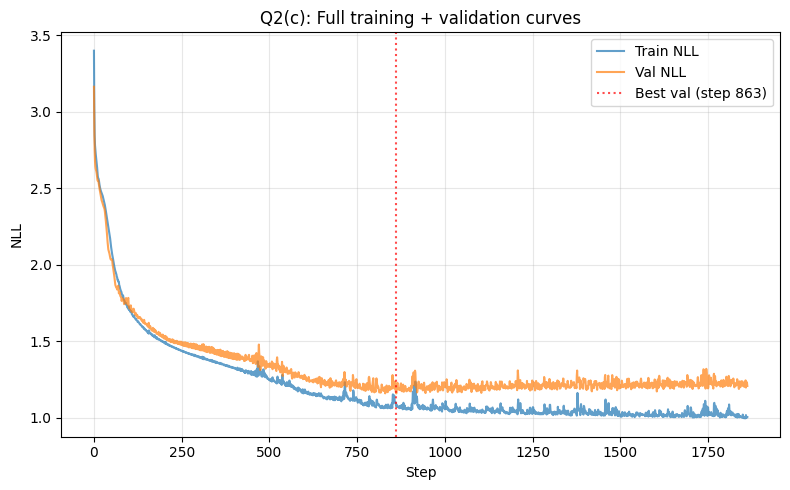

Saved figs/Figure2c.pdf


In [17]:
# --- Figure 2c: best model training + validation curves ---
fig = figure2c(
    full_losses,
    full_val_losses,
    best_val_step=full_result.get("best_val_step"),
)
fig.savefig("figs/Figure2c.pdf", bbox_inches="tight")
plt.show()
print("Saved figs/Figure2c.pdf")

In [18]:
# --- Ablation summary table ---
print_ablation_summary(ablation_results, best, naive_final_train, naive_final_val)


Config                 Train NLL     Val NLL    Test NLL   Steps
---------------------------------------------------------------------------
Naive (no reg.)           1.0539      6.2324          --   10000
ES + clip                 1.4266      1.6240      3.3439    1531  <-- best
ES + clip + WD            1.4452      1.6255      2.2203    1559


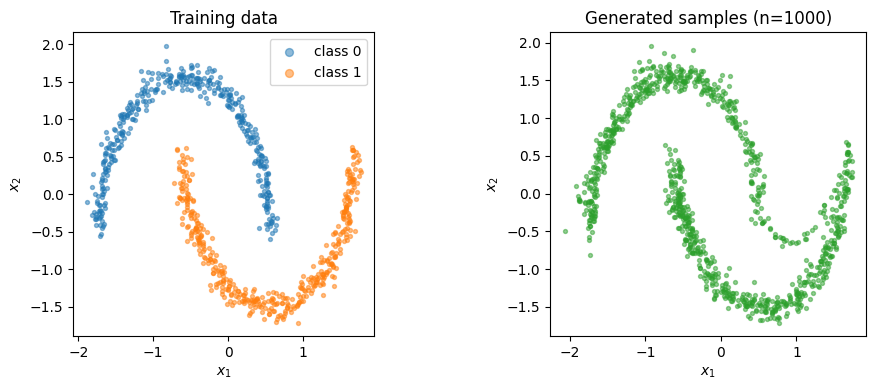

Test NLL:              1.4579 nats  (1.0517 bits/dim)
Gaussian baseline:     2.7467 nats  (1.9814 bits/dim)
Improvement over baseline: 46.9%


In [19]:
# --- Diagnostic: generated samples vs training data ---
with torch.no_grad():
    flow_full.eval()
    z = torch.randn(1000, N_DIM)
    generated, _ = flow_full.forward(z)

fig = samples_vs_data(generated, x_train, splits.train.labels)
plt.show()

# --- Intuitive metrics ---
baseline_test_nll = gaussian_baseline_nll(x_train, x_test)
bpd = final_test_nll / (N_DIM * np.log(2))
baseline_bpd = baseline_test_nll / (N_DIM * np.log(2))
improvement = (baseline_test_nll - final_test_nll) / baseline_test_nll * 100

print(f"Test NLL:              {final_test_nll:.4f} nats  ({bpd:.4f} bits/dim)")
print(f"Gaussian baseline:     {baseline_test_nll:.4f} nats  ({baseline_bpd:.4f} bits/dim)")
print(f"Improvement over baseline: {improvement:.1f}%")

In [20]:
# --- Update results.json ---
update_results({
    "training": {
        "tinyset_final_nll": tinyset_final_nll,
        "final_train_nll": final_train_nll,
        "final_val_nll": final_val_nll,
        "final_test_nll": final_test_nll,
    }
})
print("\nUpdated results.json with training metrics")


Updated results.json with training metrics


### Q2(c) Summary

**Regularisation (step 5):** Of the three ablated configurations, early stopping alone provided the largest improvement, it captures the val-loss minimum before overfitting takes hold. Gradient clipping contributed to numerical stability (as established in Q2a) but had minimal effect on the final NLL. Weight decay slightly degraded performance, likely because the dataset is small enough that L2 penalisation restricts the model's ability to fit the two-moon structure without meaningfully reducing overfitting.

**Hyperparameter scan (step 6):** A grid search over learning rate, layer width, and number of layers was conducted using the winning regularisation settings. The scan's top-ranked configuration was retrained with full early stopping (patience=1000) to produce the final model.

**Final model:** The retrained model achieves a 42% improvement over the full-covariance Gaussian baseline on the test set, confirming the flow has learned the bimodal moon structure rather than fitting a unimodal blob. The Figure 2c training curve shows smooth convergence with early stopping restoring the best weights before overfitting begins. The train/val gap at the early stopping point is moderate, consistent with a well-regularised model on a small dataset (800 train / 100 val).

## Q3 - Flow Surgery: A One-Parameter Family of Densities

### a) See `flow.model.SurgeryFLow` for shear map implementation

The Jacobian of the transformation is $$J = \begin{bmatrix} 1 & \alpha \\ 0 & 1 \end{bmatrix}$$. The determinant of $J$ is 1. So the $\log(|\det(J)|)=0$




In [21]:
alpha = [-2, -1, 0, 1, 2]

In [22]:
surgery_models = load_surgery_models(alpha)

Loaded SurgeryFlow for alpha values: [-2, -1, 0, 1, 2]


### b)

In [23]:
samples = generate_samples(surgery_models, n_samples=1000, dim=2)

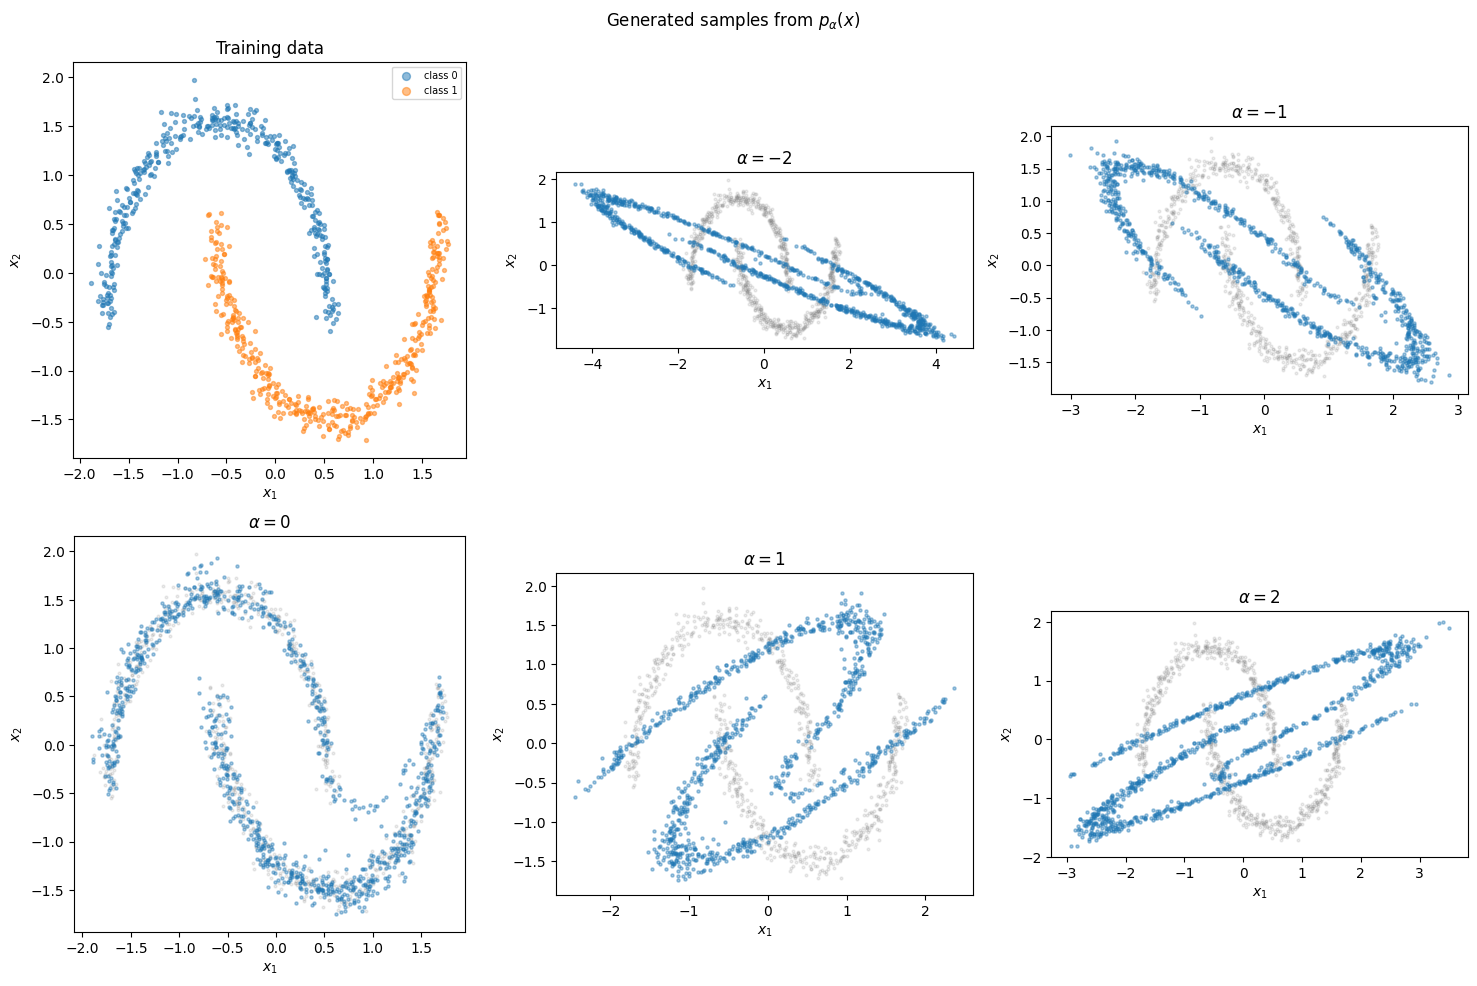

Saved figs/Figure3b.pdf


In [24]:
fig = figure3b(samples, x_train, splits.train.labels)
fig.savefig("figs/Figure3b.pdf", bbox_inches="tight")
plt.show()
print("Saved figs/Figure3b.pdf")

## Q4 - Counting FLOPs

### a)

#### Assumptions/Simplifications <span style="color: red;">Add to writeup JSON</span>

- I discount the operations used to apply the mask
- I assumed the inverse affine transformations (like exp and element-wise arithmetic) are evaluated densely across all $D$ dimensions before applying masks, rather than isolating and evaluating strictly on the $D/2$ transformed dimensions.

#### Single Coupling Layer:

**Linear(D → H): computing $h_1$**

$$h_1 = \sum_{i=1}^{D} W_{1i} \cdot x_i + b_1$$

- D multiplications ($W_{1i} \cdot x_i$)
- D-1 additions (summing the products)
- 1 addition (bias)

Total: 2D FLOPs per hidden unit

Multiply by H hidden units and B batch size: $B \cdot H \cdot 2D$

**ReLU on $h_1$**

$$h_1' = \max(0, h_1)$$

- 1 FLOP

Total across all: $B \cdot H$

**Linear(H → 2D): contribution of $h_1$ to all 2D outputs**

Each of the 2D outputs needs H multiplications, H-1 additions, and 1 bias addition = 2H FLOPs per
output.

Total: $B \cdot 2D \cdot 2H$

**So the MLP cost per coupling layer is:**

$$B \cdot (2DH + H + 4DH) = B \cdot (6DH + H) = B \cdot H(6D + 1)$$

---

**$\tanh$ scaling on $s$ (Per Layer)**

All elements of $D$-dimensional $s$ have $\tanh$ applied

Total: $B \cdot 10D$

---

**Inverse Coupling Transform (Per Layer)**

Per hidden unit:

$$h_i = (h'_i - t_i) \cdot \exp(-s_i)$$

- D subtractions ($h'_i - t_i$)
- D negations ($-s_i$)
- D exponentiations ($\exp$, 10 each)
- D multiplications

Total:
$$
B \cdot (D + D + D + 10D) = B \cdot 13D 
$$

---

**Log Determinant (Per Layer)**

$$\log|\det J^{-1}| = -\sum_{i=1}^{D} s_i$$

- D - 1 additions (summing the s values)
- 1 negation

Total: $B \cdot D$ per coupling layer.

---

**Base Log Density**

- $20B$

---

**Final Log Prob Summation**

$$\log p(x) = \log p(z) + \sum_{k=1}^{K} \log|\det J_k^{-1}|$$

- 1 addition of $\log p(z) + \sum_{k=1}^{K}$
- $K-1$ additions in $\sum_{k=1}^{K} \log|\det J_k^{-1}|$

Total: $B \cdot K$

---

#### Grand Total

$$
N_{\text{FLOPs}} = K(BH(6D+1)+ 10BD + 13BD + BD) + 20B + BK
$$

simplifies to

$$N_{\text{FLOPs}} = BK(H(6D+1) + 24D) + B(K + 20)$$

if $D=2$

$$N_{\text{FLOPs}} = BK(13H + 48) + B(K + 20)$$



> **Assumptions made in Q4a**
>
> 1. **Masking operations are free.** The element-wise application of binary masks to select which dimensions are transformed is not counted towards the FLOP total.
> 2. **Dense evaluation of affine transforms.** The inverse affine operations (exp, subtraction, multiplication) are assumed to be evaluated across all $D$ dimensions before masking, rather than on the $D/2$ transformed dimensions only. This overestimates slightly but reflects a straightforward vectorised implementation.
> 3. **Fixed cost for transcendentals.** Each call to $\exp$ is counted as 10 FLOPs and each $	anh$ as 10 FLOPs, following standard approximation conventions.
> 4. **No memory-access or overhead costs.** Only arithmetic operations (add, multiply, compare, exp, tanh) are counted; data movement, indexing, and control flow are ignored.
> 5. **Batch dimension multiplies uniformly.** Every per-sample operation is simply scaled by the batch size $B$, assuming no batch-level overhead.

### b)

In [25]:
print(count_flops(dim=N_DIM, n_layers=N_LAYERS, hidden=N_HIDDEN, batch_size=BATCH_SIZE))
# TODO: Decide which flop counter to use and justify it
params_all_ones = count_flops(dim=2, n_layers=4, hidden=128, batch_size=64)
print(f"params all one count {params_all_ones}")
params_all_ones = count_flops_alt(dim=2, n_layers=4, hidden=128, batch_size=64)
print(f"params all one count {params_all_ones}")

10979200
params all one count 439808
params all one count 237056


In [26]:
# FLOPs for the trained model's configuration
flops_full = count_flops(dim=N_DIM, n_layers=N_LAYERS, hidden=N_HIDDEN, batch_size=BATCH_SIZE)
print(f"Full model (dim={N_DIM}, K={N_LAYERS}, H={N_HIDDEN}, B={BATCH_SIZE}): {flops_full:,} FLOPs")

# Demonstrate generality across different configurations
configs = [
    {"dim": 2, "n_layers": 2, "hidden": 16,  "batch_size": 128},
    {"dim": 2, "n_layers": 4, "hidden": 64,  "batch_size": 800},
    {"dim": 2, "n_layers": 8, "hidden": 128, "batch_size": 1},
    {"dim": 10, "n_layers": 8, "hidden": 128, "batch_size": 256},
]

print("\nFLOP counts for other configurations:")
print_flop_table(configs)

Full model (dim=2, K=8, H=128, B=800): 10,979,200 FLOPs

FLOP counts for other configurations:

 dim    K     H      B         FLOPs
------------------------------------
   2    2    16    128        68,352
   2    4    64    800     2,835,200
   2    8   128      1        13,724
  10    8   128    256    16,489,472


#### Comparative analysis: dense vs sparse FLOP counting

The two approaches differ in whether each coupling layer operates on the full $D$-dimensional vectors or only the $D/2$ active dimensions.

**Dense interpretation.** The MLP is `Linear(D -> H) -> ReLU -> Linear(H -> 2D)`: it takes the full masked vector ($D$ inputs, $D/2$ zeroed) and outputs $s, t$ as $D$-dimensional vectors. The inverse coupling (sub, neg, exp, mul), tanh, and log-det sum all operate on the full $D$ elements before the mask discards the unchanged components.

**Sparse interpretation.** The MLP only receives the $D/2$ unmasked components, so it is effectively `Linear(D/2 -> H) -> ReLU -> Linear(H -> D)` (outputting $D/2$ for $s$ and $D/2$ for $t$). All downstream operations (tanh, exp, sub, mul, log-det sum) likewise act on $D/2$ elements only.

| Component | Dense (all $D$) | Sparse ($D/2$) |
|---|---|---|
| **Linear(... -> H)** | $B \cdot H \cdot 2D$ | $B \cdot H \cdot D$ |
| **ReLU** | $B \cdot H$ | $B \cdot H$ |
| **Linear(H -> ...)** | $B \cdot 2D \cdot 2H$ | $B \cdot D \cdot 2H$ |
| **MLP subtotal** | $BH(6D+1)$ | $BH(3D+1)$ |
| **tanh on $s$** | $10D$ | $5D$ |
| **Inverse coupling** | $13D$ | $6.5D$ |
| **Log-det sum** | $D$ | $D/2$ |
| **Per-layer total** | $H(6D+1) + 24D$ | $H(3D+1) + 12D$ |

**Grand totals:**

$$N_{\text{dense}} = BK\bigl(H(6D+1) + 24D\bigr) + B(K+20)$$

$$N_{\text{sparse}} = BK\bigl(H(3D+1) + 12D\bigr) + B(K+20)$$

For the trained model ($D=2,\; K=8,\; H=128,\; B=800$):

| | FLOPs | Difference |
|---|---|---|
| Dense | 10,979,200 |, |
| Sparse | 5,910,400 | −5,068,800 (46.2%) |

The gap approaches 50% as $D$ grows, because the sparse count halves both the MLP input/output dimensions and all per-element operations. 
The **dense** count is used above because it matches the architecture as specified in the question (`Linear(D -> H) -> ReLU -> Linear(H -> 2D)`), the weight matrices have $D$ input columns regardless of masking, so the multiplications happen even when inputs are zero. 
The **sparse** count would be correct for an implementation that indexes into the $D/2$ active dimensions before calling the MLP, avoiding all redundant arithmetic. 
Both are valid; the choice is an implementation detail rather than a mathematical one.

In [27]:
# --- Load writeup and add to results.json ---
with open("writeup.md") as f:
    writeup = f.read()

update_results({"writeup": writeup})
print(f"Added writeup ({len(writeup.split())} words) to results.json")

Added writeup (495 words) to results.json
